In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set up the path
logs_path = '../outputs/logs/'

# Define models to visualize
models = {
    'ResNet50': 'baseline_resnet50_metrics.csv',
    'DenseNet121': 'baseline_densenet121_metrics.csv',
    'MobileNetV2': 'baseline_mobilenetv2_metrics.csv',
    'EfficientNet-B0': 'baseline_efficientnet_b0_metrics.csv'
}

# Load data|
data = {}
for model_name, filename in models.items():
    filepath = os.path.join(logs_path, filename)
    data[model_name] = pd.read_csv(filepath)
    print(f"Loaded {model_name}: {filepath}")
    print(data[model_name])

Loaded ResNet50: ../outputs/logs/baseline_resnet50_metrics.csv
    epoch  train_loss  train_accuracy  val_accuracy
0       1    0.187595       93.514604     97.463490
1       2    0.099272       96.651614     93.889316
2       3    0.079720       97.223290     89.892390
3       4    0.067904       97.751729     98.539585
4       5    0.058489       98.006341     96.771714
5       6    0.054399       98.131245     98.193697
6       7    0.046747       98.395465     97.578786
7       8    0.042672       98.501153     98.539585
8       9    0.039421       98.616449     98.885473
9      10    0.036854       98.779785     98.847041
10     11    0.034778       98.774981     98.847041
11     12    0.032289       98.847041     98.654881
12     13    0.029956       98.976749     98.923905
13     14    0.024206       99.144889     97.617218
14     15    0.028808       98.991161     98.923905
Loaded DenseNet121: ../outputs/logs/baseline_densenet121_metrics.csv
    epoch  train_loss  train_accurac

In [20]:
# Load fine-tuned metrics and evaluation results
finetuned_models = {
    'ResNet50': 'evaluation_results_resnet50_finetuned.csv',
    'DenseNet121': 'evaluation_results_densenet121_finetuned.csv',
    'MobileNetV2': 'evaluation_results_mobilenetv2_finetuned.csv',
    'EfficientNet-B0': 'evaluation_results_efficientnet_b0_finetuned.csv'
}

baseline_eval_models = {
    'ResNet50': 'evaluation_results_resnet50_baseline.csv',
    'DenseNet121': 'evaluation_results_densenet121_baseline.csv',
    'MobileNetV2': 'evaluation_results_mobilenetv2_baseline.csv',
    'EfficientNet-B0': 'evaluation_results_efficientnet_b0_baseline.csv'
}

baseline_eval = {}
finetuned_eval = {}

print("Loading evaluation results...")
for model_name in models.keys():
    # Load baseline
    baseline_path = os.path.join(logs_path, baseline_eval_models[model_name])
    print(f"  Loading baseline: {baseline_path}")
    if os.path.exists(baseline_path):
        baseline_eval[model_name] = pd.read_csv(baseline_path)
        print(f"    ✓ Loaded successfully")
    else:
        print(f"    ✗ File not found: {baseline_path}")
    
    # Load fine-tuned
    finetuned_path = os.path.join(logs_path, finetuned_models[model_name])
    print(f"  Loading fine-tuned: {finetuned_path}")
    if os.path.exists(finetuned_path):
        finetuned_eval[model_name] = pd.read_csv(finetuned_path)
        print(f"    ✓ Loaded successfully")
    else:
        print(f"    ✗ File not found: {finetuned_path}")

print(f"\n✓ Loaded {len(baseline_eval)} baseline models and {len(finetuned_eval)} fine-tuned models")

Loading evaluation results...
  Loading baseline: ../outputs/logs/evaluation_results_resnet50_baseline.csv
    ✓ Loaded successfully
  Loading fine-tuned: ../outputs/logs/evaluation_results_resnet50_finetuned.csv
    ✓ Loaded successfully
  Loading baseline: ../outputs/logs/evaluation_results_densenet121_baseline.csv
    ✓ Loaded successfully
  Loading fine-tuned: ../outputs/logs/evaluation_results_densenet121_finetuned.csv
    ✓ Loaded successfully
  Loading baseline: ../outputs/logs/evaluation_results_mobilenetv2_baseline.csv
    ✓ Loaded successfully
  Loading fine-tuned: ../outputs/logs/evaluation_results_mobilenetv2_finetuned.csv
    ✓ Loaded successfully
  Loading baseline: ../outputs/logs/evaluation_results_efficientnet_b0_baseline.csv
    ✓ Loaded successfully
  Loading fine-tuned: ../outputs/logs/evaluation_results_efficientnet_b0_finetuned.csv
    ✓ Loaded successfully

✓ Loaded 4 baseline models and 4 fine-tuned models


In [21]:
print("" * 80)
print("RESEARCH ANALYSIS: BASELINE VS FINE-TUNED MODEL COMPARISON")
print("=" * 80)


RESEARCH ANALYSIS: BASELINE VS FINE-TUNED MODEL COMPARISON


In [22]:
# TABLE 1: Summary Comparison (Training Performance)
print("\n" + "=" * 80)
print("TABLE 1: TRAINING PERFORMANCE SUMMARY")
print("=" * 80)

summary_data = []
for model_name, df in data.items():
    summary_data.append({
        'Model': model_name,
        'Epochs': len(df),
        'Initial Train Loss': f'{df["train_loss"].iloc[0]:.4f}',
        'Final Train Loss': f'{df["train_loss"].iloc[-1]:.4f}',
        'Min Train Loss': f'{df["train_loss"].min():.4f}',
        'Final Train Acc (%)': f'{df["train_accuracy"].iloc[-1]:.2f}',
        'Final Val Acc (%)': f'{df["val_accuracy"].iloc[-1]:.2f}',
        'Max Val Acc (%)': f'{df["val_accuracy"].max():.2f}'
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()


TABLE 1: TRAINING PERFORMANCE SUMMARY
          Model  Epochs Initial Train Loss Final Train Loss Min Train Loss Final Train Acc (%) Final Val Acc (%) Max Val Acc (%)
       ResNet50      15             0.1876           0.0288         0.0242               98.99             98.92           98.92
    DenseNet121      15             0.1836           0.0201         0.0199               99.32             98.50           99.35
    MobileNetV2      15             0.1765           0.0210         0.0210               99.33             98.96           99.12
EfficientNet-B0      15             0.2093           0.0145         0.0145               99.51             99.27           99.46



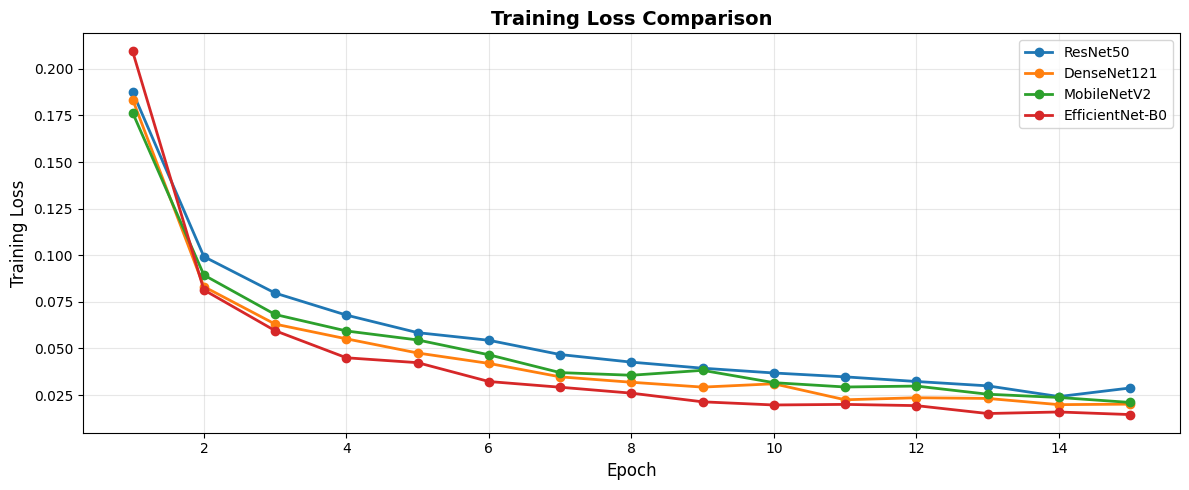

Training Loss Graph Displayed


In [23]:
# Plot Training Loss
plt.figure(figsize=(12, 5))

for model_name, df in data.items():
    plt.plot(df['epoch'], df['train_loss'], marker='o', label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Training Loss Graph Displayed")

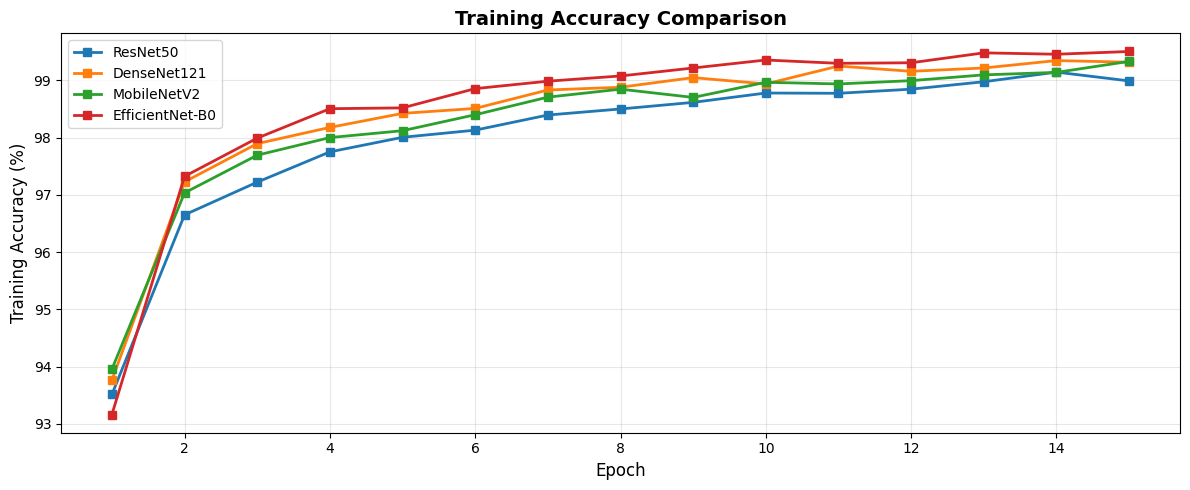

Training Accuracy Graph Displayed


In [24]:
# Plot Training Accuracy
plt.figure(figsize=(12, 5))

for model_name, df in data.items():
    plt.plot(df['epoch'], df['train_accuracy'], marker='s', label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Accuracy (%)', fontsize=12)
plt.title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Training Accuracy Graph Displayed")

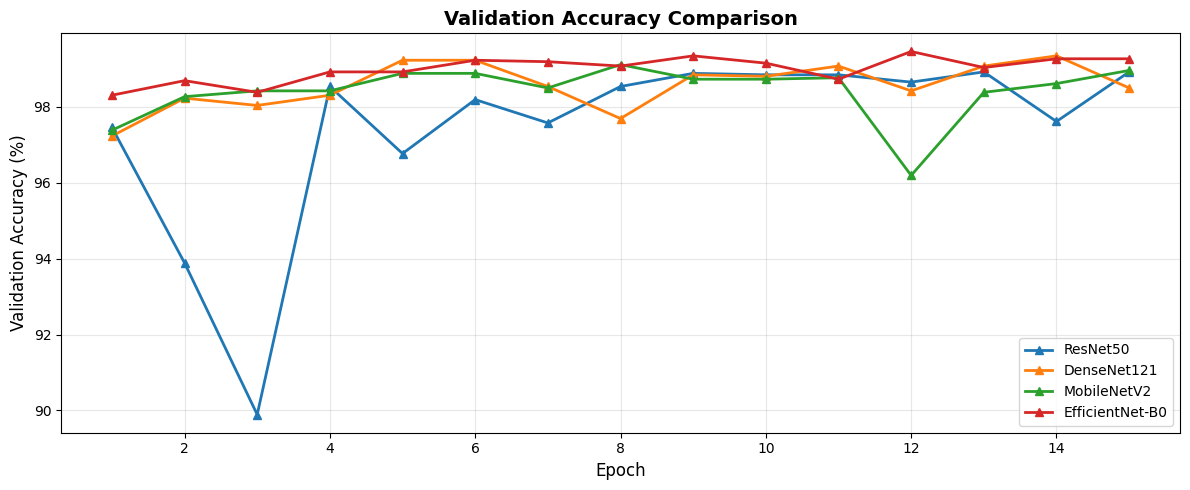

Validation Accuracy Graph Displayed


In [25]:
# Plot Validation Accuracy
plt.figure(figsize=(12, 5))

for model_name, df in data.items():
    plt.plot(df['epoch'], df['val_accuracy'], marker='^', label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Validation Accuracy Graph Displayed")

In [26]:
# Create Baseline Training Comparison Table
comparison_data = []

for model_name, df in data.items():
    min_loss = df['train_loss'].min()
    final_train_acc = df['train_accuracy'].iloc[-1]
    final_val_acc = df['val_accuracy'].iloc[-1]
    max_val_acc = df['val_accuracy'].max()
    min_loss_epoch = df[df['train_loss'] == min_loss]['epoch'].values[0]
    
    comparison_data.append({
        'Model': model_name,
        'Min Training Loss': f'{min_loss:.6f}',
        'Loss @ Epoch': int(min_loss_epoch),
        'Final Train Accuracy': f'{final_train_acc:.2f}%',
        'Final Val Accuracy': f'{final_val_acc:.2f}%',
        'Max Val Accuracy': f'{max_val_acc:.2f}%',
        'Epochs': len(df)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Baseline Training Comparison Table ===")
print(comparison_df.to_string(index=False))


=== Baseline Training Comparison Table ===
          Model Min Training Loss  Loss @ Epoch Final Train Accuracy Final Val Accuracy Max Val Accuracy  Epochs
       ResNet50          0.024206            14               98.99%             98.92%           98.92%      15
    DenseNet121          0.019868            14               99.32%             98.50%           99.35%      15
    MobileNetV2          0.021047            15               99.33%             98.96%           99.12%      15
EfficientNet-B0          0.014545            15               99.51%             99.27%           99.46%      15


In [27]:
# TABLE 2: Test Accuracy - Baseline vs Fine-tuned + Improvement
print("\n" + "=" * 80)
print("TABLE 2: TEST ACCURACY COMPARISON (BASELINE vs FINE-TUNED)")
print("=" * 80)

accuracy_data = []
for model_name in models.keys():
    baseline_acc = baseline_eval[model_name][baseline_eval[model_name]['Metric'] == 'Test Accuracy']['Value'].values[0]
    finetuned_acc = finetuned_eval[model_name][finetuned_eval[model_name]['Metric'] == 'Test Accuracy']['Value'].values[0]
    improvement = ((finetuned_acc - baseline_acc) / baseline_acc) * 100
    
    accuracy_data.append({
        'Model': model_name,
        'Baseline Accuracy': f'{baseline_acc*100:.2f}%',
        'Fine-tuned Accuracy': f'{finetuned_acc*100:.2f}%',
        'Absolute Change': f'{(finetuned_acc-baseline_acc)*100:.2f}%',
        'Improvement (%)': f'{improvement:.2f}%'
    })

accuracy_df = pd.DataFrame(accuracy_data)
print(accuracy_df.to_string(index=False))
print()


TABLE 2: TEST ACCURACY COMPARISON (BASELINE vs FINE-TUNED)
          Model Baseline Accuracy Fine-tuned Accuracy Absolute Change Improvement (%)
       ResNet50            98.77%              99.54%           0.77%           0.78%
    DenseNet121            99.50%              98.12%          -1.38%          -1.39%
    MobileNetV2            99.15%              99.08%          -0.08%          -0.08%
EfficientNet-B0            99.27%              95.20%          -4.07%          -4.10%



Extracting accuracy values:
  ✓ ResNet50: Baseline=98.77%, Fine-tuned=99.54%
  ✓ DenseNet121: Baseline=99.50%, Fine-tuned=98.12%
  ✓ MobileNetV2: Baseline=99.15%, Fine-tuned=99.08%
  ✓ EfficientNet-B0: Baseline=99.27%, Fine-tuned=95.20%


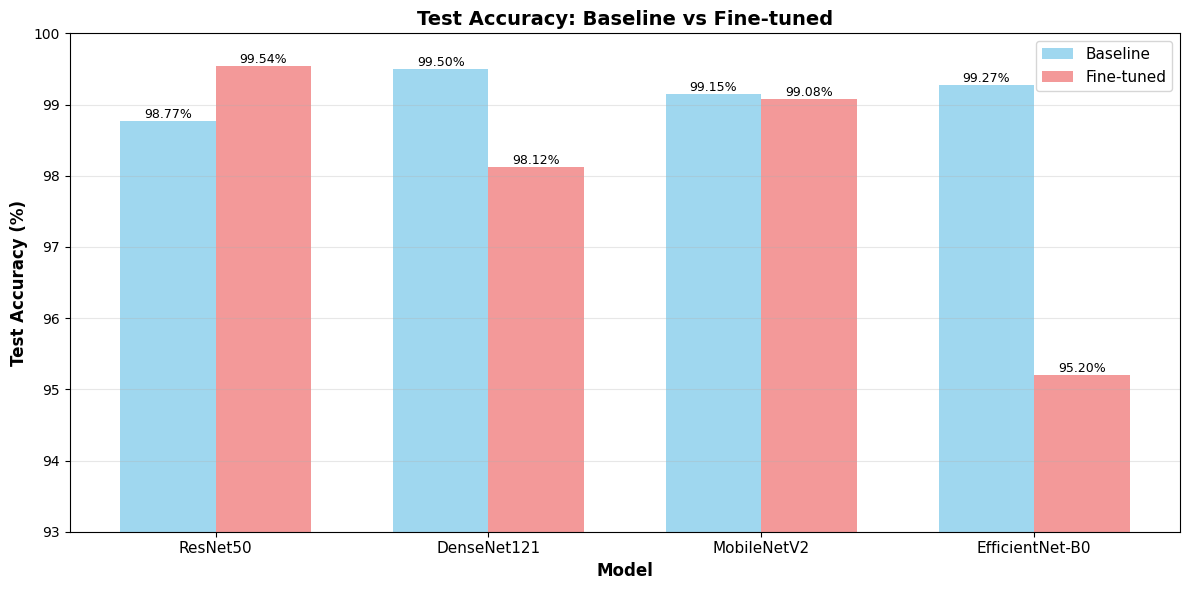


✓ Test Accuracy Comparison Chart Displayed (4 models)
  Y-axis range: 93% - 100%


In [34]:
# VISUALIZATION: Test Accuracy Improvement
plt.figure(figsize=(12, 6))

x = np.arange(len(models))
width = 0.35

baseline_accs = []
finetuned_accs = []
model_names_present = []

print("Extracting accuracy values:")
for model_name in models.keys():
    # Check if model data exists
    if model_name not in baseline_eval or model_name not in finetuned_eval:
        print(f"  ⚠ {model_name}: MISSING DATA - skipping")
        continue
    
    try:
        baseline_acc = baseline_eval[model_name][baseline_eval[model_name]['Metric'] == 'Test Accuracy']['Value'].values[0]
        finetuned_acc = finetuned_eval[model_name][finetuned_eval[model_name]['Metric'] == 'Test Accuracy']['Value'].values[0]
        
        baseline_accs.append(baseline_acc * 100)
        finetuned_accs.append(finetuned_acc * 100)
        model_names_present.append(model_name)
        
        print(f"  ✓ {model_name}: Baseline={baseline_acc*100:.2f}%, Fine-tuned={finetuned_acc*100:.2f}%")
    except Exception as e:
        print(f"  ✗ {model_name}: ERROR - {str(e)}")

if not baseline_accs:
    print("\n❌ No data available to plot!")
else:
    # Update x positions based on number of models
    x = np.arange(len(model_names_present))
    
    bars1 = plt.bar(x - width/2, baseline_accs, width, label='Baseline', alpha=0.8, color='skyblue')
    bars2 = plt.bar(x + width/2, finetuned_accs, width, label='Fine-tuned', alpha=0.8, color='lightcoral')

    plt.xlabel('Model', fontsize=12, fontweight='bold')
    plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    plt.title('Test Accuracy: Baseline vs Fine-tuned', fontsize=14, fontweight='bold')
    plt.xticks(x, model_names_present, fontsize=11)
    
    # Adjust y-axis to show all bars (find min value and round down)
    min_acc = min(min(baseline_accs), min(finetuned_accs))
    max_acc = max(max(baseline_accs), max(finetuned_accs))
    y_min = int(min_acc) - 2  # Add 2% margin below
    y_max = int(max_acc) + 1  # Add 1% margin above
    plt.ylim([y_min, y_max])
    
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"\n✓ Test Accuracy Comparison Chart Displayed ({len(model_names_present)} models)")
    print(f"  Y-axis range: {y_min}% - {y_max}%")

In [32]:
# TABLE 3: Per-Class Recall (Key Insight - Disease Detection Reliability)
print("\n" + "=" * 80)
print("TABLE 3: PER-CLASS RECALL SCORES (Disease Detection Capability)")
print("=" * 80)
print("\nBASELINE MODELS:")

for model_name in models.keys():
    if model_name not in baseline_eval:
        print(f"\n{model_name}: ⚠ DATA NOT AVAILABLE")
        continue
        
    baseline = baseline_eval[model_name]
    print(f"\n{model_name}:")
    recall_metrics = baseline[baseline['Metric'].str.contains('Recall')]
    if len(recall_metrics) == 0:
        print("  ⚠ No recall metrics found")
    else:
        for _, row in recall_metrics.iterrows():
            print(f"  {row['Metric']}: {float(row['Value'])*100:.2f}%")

print("\n\nFINE-TUNED MODELS:")
for model_name in models.keys():
    if model_name not in finetuned_eval:
        print(f"\n{model_name}: ⚠ DATA NOT AVAILABLE")
        continue
        
    finetuned = finetuned_eval[model_name]
    print(f"\n{model_name}:")
    recall_metrics = finetuned[finetuned['Metric'].str.contains('Recall')]
    if len(recall_metrics) == 0:
        print("  ⚠ No recall metrics found")
    else:
        for _, row in recall_metrics.iterrows():
            print(f"  {row['Metric']}: {float(row['Value'])*100:.2f}%")
print()


TABLE 3: PER-CLASS RECALL SCORES (Disease Detection Capability)

BASELINE MODELS:

ResNet50:
  Normal - Recall: 99.29%
  Pneumonia - Recall: 99.11%
  COVID-19 - Recall: 96.96%
  Tuberculosis - Recall: 95.87%

DenseNet121:
  Normal - Recall: 99.55%
  Pneumonia - Recall: 99.82%
  COVID-19 - Recall: 98.90%
  Tuberculosis - Recall: 99.17%

MobileNetV2:
  Normal - Recall: 99.87%
  Pneumonia - Recall: 97.86%
  COVID-19 - Recall: 98.34%
  Tuberculosis - Recall: 98.35%

EfficientNet-B0:
  Normal - Recall: 99.36%
  Pneumonia - Recall: 99.11%
  COVID-19 - Recall: 99.17%
  Tuberculosis - Recall: 99.17%


FINE-TUNED MODELS:

ResNet50:
  Normal - Recall: 99.74%
  Pneumonia - Recall: 99.29%
  COVID-19 - Recall: 99.45%
  Tuberculosis - Recall: 98.35%

DenseNet121:
  Normal - Recall: 99.10%
  Pneumonia - Recall: 97.69%
  COVID-19 - Recall: 96.41%
  Tuberculosis - Recall: 92.56%

MobileNetV2:
  Normal - Recall: 99.55%
  Pneumonia - Recall: 98.75%
  COVID-19 - Recall: 98.07%
  Tuberculosis - Recall: 97

In [ ]:
# TABLE 4: Average F1-Score Comparison
print("\n" + "=" * 80)
print("TABLE 4: AVERAGE F1-SCORE COMPARISON")
print("=" * 80)

f1_data = []
for model_name in models.keys():
    if model_name not in baseline_eval or model_name not in finetuned_eval:
        print(f"⚠ {model_name}: MISSING DATA - skipping")
        continue
        
    baseline = baseline_eval[model_name]
    finetuned = finetuned_eval[model_name]
    
    baseline_f1_values = baseline[baseline['Metric'].str.contains('F1-Score')]['Value'].astype(float).values
    finetuned_f1_values = finetuned[finetuned['Metric'].str.contains('F1-Score')]['Value'].astype(float).values
    
    if len(baseline_f1_values) == 0 or len(finetuned_f1_values) == 0:
        print(f"⚠ {model_name}: Missing F1-Score metrics - skipping")
        continue
    
    baseline_avg_f1 = baseline_f1_values.mean()
    finetuned_avg_f1 = finetuned_f1_values.mean()
    
    f1_data.append({
        'Model': model_name,
        'Baseline Avg F1': f'{baseline_avg_f1:.4f}',
        'Fine-tuned Avg F1': f'{finetuned_avg_f1:.4f}',
        'Improvement': f'{(finetuned_avg_f1 - baseline_avg_f1):.4f}'
    })

if f1_data:
    f1_df = pd.DataFrame(f1_data)
    print(f1_df.to_string(index=False))
else:
    print("❌ No F1-Score data available")
print()


TABLE 4: AVERAGE F1-SCORE COMPARISON
          Model Baseline Avg F1 Fine-tuned Avg F1 Improvement
       ResNet50          0.9834            0.9933      0.0099
    DenseNet121          0.9938            0.9735     -0.0203
    MobileNetV2          0.9905            0.9878     -0.0028
EfficientNet-B0          0.9906            0.9400     -0.0506

